# Triple Exponential Model

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import ExponentialSmoothing, SimpleExpSmoothing, Holt

In [2]:
data=pd.read_csv(r"C:\Users\Hp\Desktop\Python Code\Time Series - Student\Python\ES Model\AirPassenger.csv")
data.head(5)

,Date,Passenger
0,01-01-1949,112
1,01-02-1949,118
2,01-03-1949,132
3,01-04-1949,129
4,01-05-1949,121


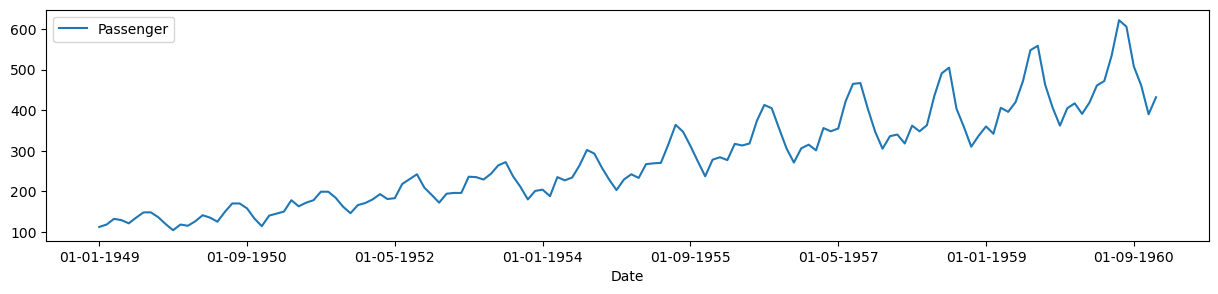

In [3]:
data.plot.line(x = 'Date',y = 'Passenger',figsize=(15,3))
plt.show()  # Trend , Seasonal

In [4]:
data2 = data.set_index("Date")
data2.head()

,Passenger
Date,
01-01-1949,112
01-02-1949,118
01-03-1949,132
01-04-1949,129
01-05-1949,121


abc=np.array([0.88,0.93,1.04,1.02,0.96,1.07,1.17,1.17,1.07,0.94,0.82,0.93])

#### Auto Model

In [5]:
model2 = ExponentialSmoothing(data2,trend='add',seasonal='mul',seasonal_periods=12).fit()
model2.params
          # initial_seasons=np.array([0.88,0.93,1.04,1.02,0.96,1.07,1.17,1.17,1.07,0.94,0.82,0.93]))

C:\Users\Hp\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


{'smoothing_level': 0.31854364546659575,
 'smoothing_trend': 1.942692573566128e-07,
 'smoothing_seasonal': 0.601290956275535,
 'damping_trend': nan,
 'initial_level': 102.58012103663492,
 'initial_trend': 2.41199607647178,
 'initial_seasons': array([1.06120741, 1.11604797, 1.23241639, 1.17563853, 1.09751763,
        1.19857022, 1.30330647, 1.28729856, 1.17365925, 1.02381092,
        0.9066128 , 1.0383585 ]),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

In [6]:
df = pd.DataFrame(
    np.c_[data.Passenger, model2.level, model2.trend, model2.season,model2.fittedvalues],
    columns=["Actual","Level","Trend","Seasonal","Forecast"])
df

,Actual,Level,Trend,Seasonal,Forecast
0,112.0,105.166693,2.411996,1.064538,111.418413
1,118.0,106.989872,2.411996,1.104517,120.062977
2,132.0,108.670743,2.411996,1.216870,134.828655
3,129.0,110.651069,2.411996,1.167015,130.593148
4,121.0,112.166598,2.411996,1.081091,124.088708
...,...,...,...,...,...
139,606.0,430.410611,2.411994,1.411755,625.005704
140,508.0,433.164191,2.411994,1.172534,506.744517
141,461.0,441.144358,2.411995,1.042087,443.213419
142,390.0,442.302069,2.411995,0.882397,393.493133


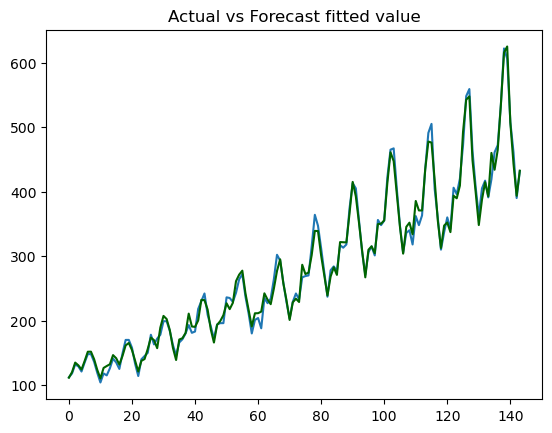

In [7]:
# Plot
plt.plot(df.Actual)
plt.plot(df.Forecast, color='darkgreen')
plt.title("Actual vs Forecast fitted value")
plt.show()

### Future Forecast 

In [8]:
Forecast2 = model2.forecast(36)
Forecast2

C:\Users\Hp\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


144    445.243672
145    418.226795
146    465.313688
147    494.949772
148    505.476830
149    573.315096
150    663.597469
151    654.905853
152    546.760868
153    488.445875
154    415.724391
155    460.378848
156    474.073185
157    445.161630
158    495.121063
159    526.487240
160    537.514949
161    609.462016
162    705.217922
163    695.767604
164    580.698636
165    518.607982
166    441.264434
167    488.518177
168    502.902698
169    472.096465
170    524.928437
171    558.024709
172    569.553067
173    645.608935
174    746.838374
175    736.629354
176    614.636404
177    548.770089
178    466.804477
179    516.657507
dtype: float64

#### Forecast Plot

<Axes: xlabel='Date'>

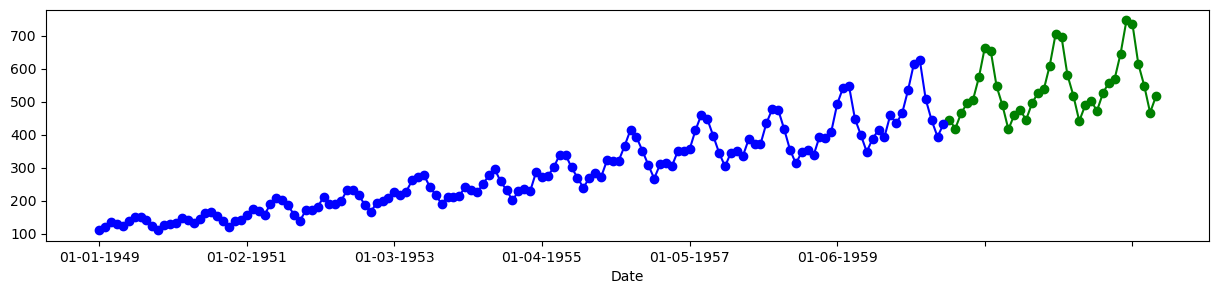

In [9]:
# plot
Forecast2.plot(marker='o', color='green')
model2.fittedvalues.plot(marker='o',  color='blue',figsize=(15,3))

In [10]:
data2["Forecast"] = model2.fittedvalues
data2.head()

,Passenger,Forecast
Date,,
01-01-1949,112,111.418413
01-02-1949,118,120.062977
01-03-1949,132,134.828655
01-04-1949,129,130.593148
01-05-1949,121,124.088708


#### Accuracy of Model

In [11]:
mean_absolute_percentage_error = np.mean(np.abs(data2.Passenger - data2.Forecast)/np.abs(data2.Passenger))*100
mean_absolute_percentage_error

3.0839600246876193

# Finished 